# **Portafolio de Implementación: Modelo de deep learning**

A01749075. Ameyalli Contreras Sánchez

## **Introducción**
El problema de predecir el precio de cierre del Bitcoin representa un desafío clásico dentro del análisis de series temporales financieras, caracterizado por su alta volatilidad y comportamiento no lineal. En este contexto, el uso de una red neuronal LSTM (Long Short-Term Memory) resulta especialmente adecuado, ya que este tipo de arquitectura está diseñada para capturar dependencias temporales y patrones secuenciales a largo plazo dentro de los datos históricos. Al aprovechar información pasada sobre precios, volumen y variaciones porcentuales, el modelo LSTM puede aprender dinámicas complejas del mercado que influyen en la evolución del valor del Bitcoin, ofreciendo así una herramienta predictiva más robusta y precisa que los métodos estadísticos tradicionales. Esta aproximación busca, en última instancia, estimar el precio de cierre del siguiente día con base en el comportamiento histórico reciente, apoyando la toma de decisiones en entornos financieros dinámicos.

## **Datos**

### **Librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout


### **Descripción del dataset**
El conjunto de datos utilizado corresponde al histórico de precios de Bitcoin obtenido de la plataforma Kaggle y contiene información financiera esencial que describe su comportamiento a lo largo del tiempo. Cada registro representa un punto temporal (por día, generalmente) e incluye variables como el precio de apertura (Open), el precio máximo (High), el precio mínimo (Low), el precio de cierre (Price), el volumen transaccionado (Vol) y la capitalización de mercado (Change%). Este conjunto de datos permite analizar la evolución del valor de Bitcoin y capturar sus tendencias, volatilidad y cambios abruptos en diferentes periodos.

Liga a Kaggle: https://www.kaggle.com/datasets/soham1024/bitcoin-time-series-data-till-02082020/data 

### **Carga de datos**

In [2]:
df = pd.read_csv('Bitcoin Historical Data.csv')

In [3]:
df.tail()

,Date,Price,Open,High,Low,Vol.,Change %
3664,"Jul 22, 2010",0.1,0.1,0.1,0.1,2.16K,0.00%
3665,"Jul 21, 2010",0.1,0.1,0.1,0.1,0.58K,0.00%
3666,"Jul 20, 2010",0.1,0.1,0.1,0.1,0.26K,0.00%
3667,"Jul 19, 2010",0.1,0.1,0.1,0.1,0.57K,0.00%
3668,"Jul 18, 2010",0.1,0.0,0.1,0.1,0.08K,0.00%


### **Data preprocessing**
Se realizó un proceso de limpieza para homogeneizar los valores numéricos, eliminar símbolos o unidades inconsistentes en la columna de volumen y descartar los primeros años con escasa actividad (2010–2013), de modo que el modelo se concentrara en el periodo donde el mercado comenzó a mostrar un comportamiento más representativo y útil para el entrenamiento de modelos predictivos basados en series de tiempo.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3669 entries, 0 to 3668
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      3669 non-null   object
 1   Price     3669 non-null   object
 2   Open      3669 non-null   object
 3   High      3669 non-null   object
 4   Low       3669 non-null   object
 5   Vol.      3669 non-null   object
 6   Change %  3669 non-null   object
dtypes: object(7)
memory usage: 200.8+ KB


In [4]:
def convertir_volumen(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # Detectar signo
    signo = -1 if valor.startswith('-') else 1
    valor = valor.replace('-', '')  # quitar signo

    # Procesar sufijos
    if 'K' in valor:
        numero = float(valor.replace('K', '')) * 1_000
    elif 'M' in valor:
        numero = float(valor.replace('M', '')) * 1_000_000
    else:
        numero = float(valor)  # ya es numérico

    return signo * numero


In [7]:
# Eliminar símbolo % 
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

# Eliminar comas
for c in ['Price', 'Open', 'High', 'Low']:
    df[c] = df[c].astype(str).str.replace(',', '').astype(float)

# Convertir a variables numéricas
df['Vol.'] = df['Vol.'].replace('-', np.nan)
df['Vol.'] = df['Vol.'].apply(convertir_volumen)

# Convertir fecha a formato datetime y ordenar
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3669 entries, 3668 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3669 non-null   datetime64[ns]
 1   Price     3669 non-null   float64       
 2   Open      3669 non-null   float64       
 3   High      3669 non-null   float64       
 4   Low       3669 non-null   float64       
 5   Vol.      3663 non-null   float64       
 6   Change %  3669 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 229.3 KB


In [8]:
df.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
3668,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.0
3667,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.0
3666,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.0
3665,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.0
3664,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.0
3663,2010-07-23,0.1,0.1,0.1,0.1,2400.0,0.0
3662,2010-07-24,0.1,0.1,0.1,0.1,500.0,0.0
3661,2010-07-25,0.1,0.1,0.1,0.1,1550.0,0.0
3660,2010-07-26,0.1,0.1,0.1,0.1,880.0,0.0
3659,2010-07-27,0.1,0.1,0.1,0.1,3370.0,0.0


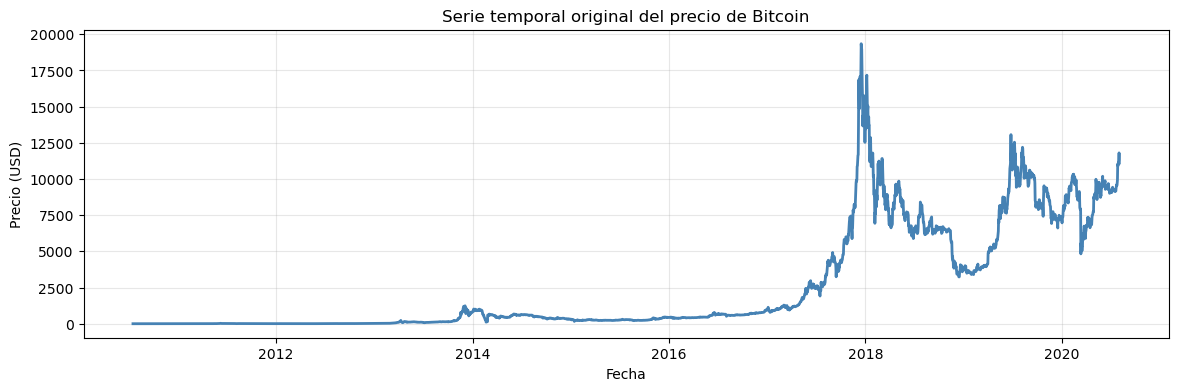

In [9]:
# Graficar la serie original completa
plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=2)

plt.title("Serie temporal original del precio de Bitcoin")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.grid(alpha=0.3)
plt.show()

In [10]:
df.shape

(3669, 7)

In [11]:
# Filtrar solo desde 2014 en adelante
df = df[df['Date'].dt.year >= 2014].reset_index(drop=True)

print(df.head(), df.tail())
print(f"Nuevas dimensiones: {df.shape}")

        Date   Price   Open    High    Low     Vol.  Change %
0 2014-01-01   815.9  805.9   829.9  771.0  10760.0      1.24
1 2014-01-02   856.9  815.9   886.2  810.5  12810.0      5.02
2 2014-01-03   884.3  856.9   888.2  839.4   9710.0      3.19
3 2014-01-04   924.7  884.3   932.2  848.3  14240.0      4.57
4 2014-01-05  1014.7  924.7  1029.9  911.4  21370.0      9.74            Date    Price     Open     High      Low      Vol.  Change %
2401 2020-07-29  11105.9  10908.4  11336.5  10771.8  576830.0      1.81
2402 2020-07-30  11096.2  11105.8  11164.4  10861.6  501140.0     -0.09
2403 2020-07-31  11333.4  11096.5  11434.8  10964.6  530950.0      2.14
2404 2020-08-01  11803.1  11333.2  11847.7  11226.1  611470.0      4.14
2405 2020-08-02  11105.8  11802.6  12061.1  10730.7  698620.0     -5.91
Nuevas dimensiones: (2406, 7)


In [12]:
# dividir en features y target
features = ['Open', 'High', 'Low', 'Vol.', 'Change %']
target = 'Price'

data = df[features + [target]].copy()
data.head()

,Open,High,Low,Vol.,Change %,Price
0,805.9,829.9,771.0,10760.0,1.24,815.9
1,815.9,886.2,810.5,12810.0,5.02,856.9
2,856.9,888.2,839.4,9710.0,3.19,884.3
3,884.3,932.2,848.3,14240.0,4.57,924.7
4,924.7,1029.9,911.4,21370.0,9.74,1014.7


In [13]:
data.shape

(2406, 6)

In [14]:
# Normalización con MinMaxScaler (esencial para LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
scaled_data

array([[3.60956590e-02, 3.39818878e-02, 3.64056337e-02, 6.71436719e-04,
        1.48331430e-01, 3.66176386e-02],
       [3.66155446e-02, 3.68382334e-02, 3.85225519e-02, 8.04298232e-04,
        1.57924121e-01, 3.87492916e-02],
       [3.87470756e-02, 3.69397022e-02, 4.00713857e-02, 6.03385700e-04,
        1.53280041e-01, 4.01738597e-02],
       ...,
       [5.71089160e-01, 5.72014916e-01, 5.82709870e-01, 3.43852077e-02,
        1.50615404e-01, 5.83438616e-01],
       [5.83394853e-01, 5.92963141e-01, 5.96724404e-01, 3.96037486e-02,
        1.55690902e-01, 6.07859041e-01],
       [6.07798284e-01, 6.03789858e-01, 5.70174498e-01, 4.52519832e-02,
        1.30186525e-01, 5.71605343e-01]])

In [15]:
scaled_data.shape

(2406, 6)

In [16]:
def create_sequences(dataset, look_back=60):
    """
    Crea secuencias de 'look_back' días para predecir el siguiente.
    """
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, :-1])  # todas las columnas menos target
        y.append(dataset[i, -1])               # target = Price 
    return np.array(X), np.array(y)

look_back = 60  # número de días de historial que observa la LSTM
X, y = create_sequences(scaled_data, look_back)

print(f"Shape X: {X.shape}, Shape y: {y.shape}")

Shape X: (2346, 60, 5), Shape y: (2346,)


### **Data Split**

In [17]:
def train_valid_test_split(features, target):
    train_size = int(0.64 * len(X))
    val_size = int(0.16 * len(X))
    test_size = len(X) - train_size - val_size

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [18]:
X_train, X_val, X_test, y_train, y_val, y_test = train_valid_test_split(X, y)
print(f"> Train shapes:       X={X_train.shape}   y={y_train.shape}")
print(f"> Validation shapes:  X={X_val.shape}    y={y_val.shape}")
print(f"> Test shapes:        X={X_test.shape}    y={y_test.shape}")

> Train shapes:       X=(1501, 60, 5)   y=(1501,)
> Validation shapes:  X=(375, 60, 5)    y=(375,)
> Test shapes:        X=(470, 60, 5)    y=(470,)


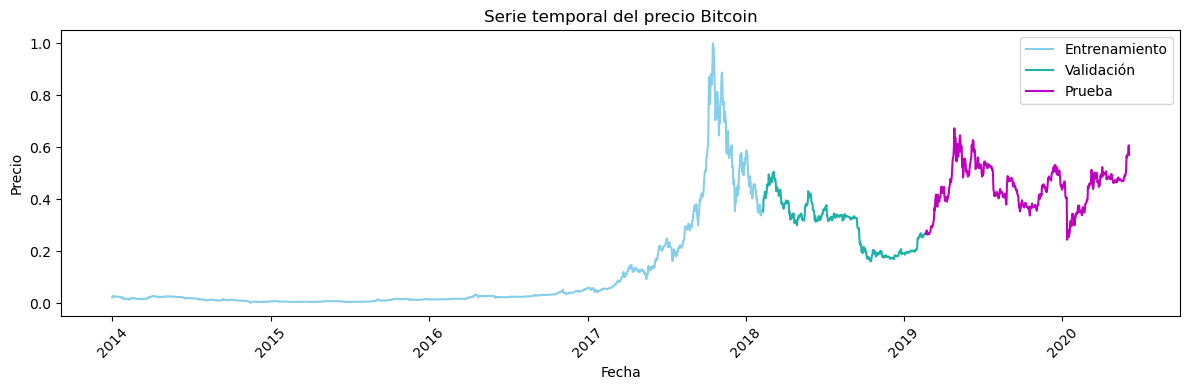

In [19]:
# Graficar train, valid y test
plt.figure(figsize=(12,4))

plt.plot(df['Date'][:len(y_train)], y_train, label='Entrenamiento', color='skyblue')
plt.plot(df['Date'][len(y_train):len(y_train)+len(y_val)], y_val, label='Validación', color='lightseagreen')
plt.plot(df['Date'][len(y_train)+len(y_val):len(y_train)+len(y_val)+len(y_test)], y_test, label='Prueba', color='m')

plt.title("Serie temporal del precio Bitcoin")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Desarrollo del modelo: LSTM**

### **Primer modelo**
La primera arquitectura propuesta consiste en una red neuronal recurrente tipo LSTM con dos capas secuenciales de 64 unidades cada una, seguidas por una capa densa intermedia de 32 neuronas con activación ReLU y una capa de salida con una sola neurona, encargada de predecir el precio de cierre del Bitcoin. Esta configuración busca capturar las relaciones temporales entre las variables históricas (precio, apertura, máximo, mínimo y volumen) y producir una estimación precisa para el día siguiente. El modelo fue diseñado como una estructura base para evaluar la capacidad de las LSTM de modelar patrones en series financieras, priorizando una arquitectura sencilla y directa sin mecanismos de regularización adicionales.

In [20]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

c:\Users\Ame Contreras\.conda\envs\deepL\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

#### **Entrenamiento**

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a observar
    patience=10,            # número de épocas sin mejora antes de detener
    restore_best_weights=True,  # restaura los pesos con mejor val_loss
    mode='min',
    verbose=1               # muestra mensaje cuando se detiene
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,              # máximo posible
    batch_size=32,
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.4640e-04 - val_loss: 0.0012
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.3315e-04 - val_loss: 0.0012
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.3232e-04 - val_loss: 0.0013
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 6.3188e-04 - val_loss: 0.0015
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 6.3998e-04 - val_loss: 9.5514e-04
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 5.7630e-04 - val_loss: 0.0012
Epoch 9/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.5080e-04 - val_loss: 9.9256e-04
Epoch 10/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.5794e-04 - val_loss: 0.0025
Epoch 11/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.6511e-04 - val_loss: 0.0011
Epoch 12

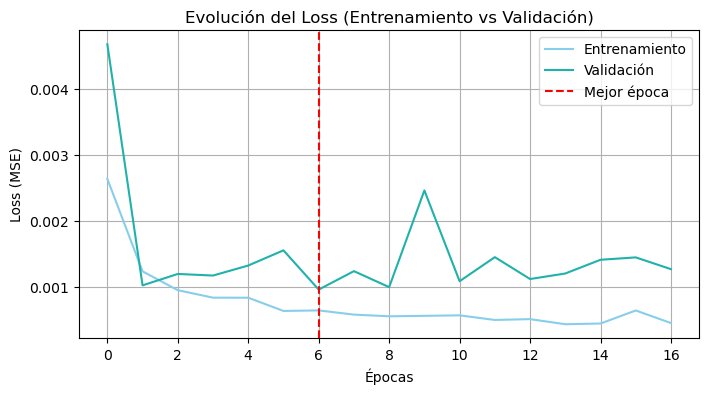

In [23]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Entrenamiento', color='skyblue')
plt.plot(history.history['val_loss'], label='Validación', color='lightseagreen')
plt.axvline(np.argmin(history.history['val_loss']), color='r', linestyle='--', label='Mejor época')
plt.title('Evolución del Loss (Entrenamiento vs Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#### **Validación**

In [24]:
y_pred_val = model.predict(X_val)

# Asegurar forma (n, 1)
y_pred_val = y_pred_val.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

# Crear arrays llenos de ceros con el mismo número de columnas que el scaler
n_cols = scaler.data_max_.shape[0]
inv_pred = np.zeros((len(y_pred_val), n_cols))
inv_true = np.zeros((len(y_val), n_cols))

# Colocar los valores predichos y reales en la última columna
inv_pred[:, -1] = y_pred_val[:, 0]
inv_true[:, -1] = y_val[:, 0]

# Invertir la transformación
y_pred_val_inv = scaler.inverse_transform(inv_pred)[:, -1]
y_val_inv = scaler.inverse_transform(inv_true)[:, -1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


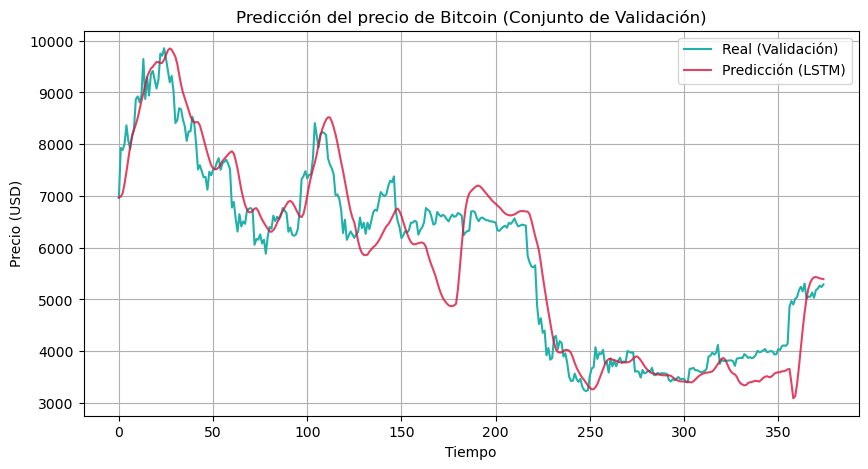

In [25]:
plt.figure(figsize=(10,5))
plt.plot(y_val_inv, label='Real (Validación)', color='lightseagreen')
plt.plot(y_pred_val_inv, label='Predicción (LSTM)', color='crimson', alpha=0.8)
plt.title('Predicción del precio de Bitcoin (Conjunto de Validación)')
plt.xlabel('Tiempo')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
mae = mean_absolute_error(y_val_inv, y_pred_val_inv)
rmse = np.sqrt(mean_squared_error(y_val_inv, y_pred_val_inv))
r2 = r2_score(y_val_inv, y_pred_val_inv)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  443.57
RMSE: 594.43
R²:   0.8842


## **Ajuste del modelo**

### **Segundo modelo**
En el segundo modelo se introdujeron ajustes estructurales orientados a mejorar el desempeño y la capacidad de generalización del modelo inicial. En el primer diseño, la red estaba compuesta por dos capas LSTM y una capa densa intermedia, sin mecanismos explícitos para controlar el sobreajuste. En la versión mejorada, se incorporaron capas Dropout con una tasa del 20% después de cada bloque LSTM, lo que permite reducir la dependencia excesiva del modelo hacia patrones específicos del conjunto de entrenamiento y fomentar una mejor generalización hacia los datos de validación y prueba. Además, se mantuvo la misma arquitectura base —dos capas LSTM con 64 unidades y una capa densa de 32 neuronas con activación ReLU—, pero ahora el modelo presenta una mayor robustez frente a la varianza y un comportamiento más estable durante el proceso de entrenamiento.

In [39]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a observar
    patience=10,            # número de épocas sin mejora antes de detener
    restore_best_weights=True,  # restaura los pesos con mejor val_loss
    mode='min',
    verbose=1               # muestra mensaje cuando se detiene
)

# Añadimos dropout para evitar sobreajuste
model_1 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_1.compile(optimizer='adam', loss='mse')

model_1.summary()

c:\Users\Ame Contreras\.conda\envs\deepL\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

#### **Entrenamiento**

In [40]:
history_1 = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,              # máximo posible
    batch_size=50,
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/200


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0081 - val_loss: 7.6521e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0014 - val_loss: 6.4235e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0015 - val_loss: 0.0032
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0015 - val_loss: 7.2616e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0026 - val_loss: 6.9803e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 9.3182e-04 - val_loss: 9.4375e-04
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0010 - val_loss: 9.5350e-04
Epoch 9/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 10/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0011 - val_loss: 4.8083e-04
Epoch 11/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 12/200
31/31 ━━━━━━━━━━━━━

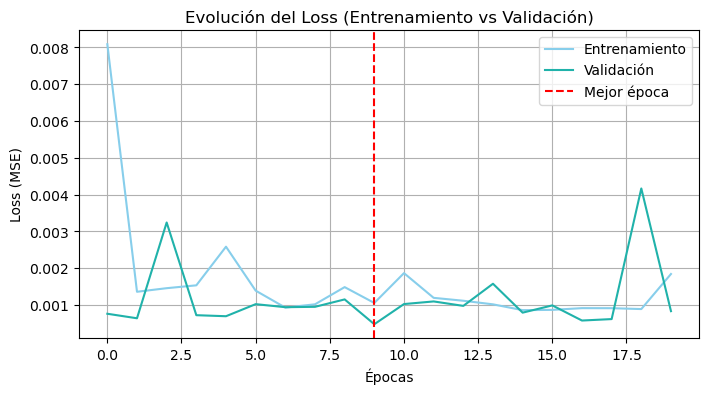

In [41]:
plt.figure(figsize=(8,4))
plt.plot(history_1.history['loss'], label='Entrenamiento', color='skyblue')
plt.plot(history_1.history['val_loss'], label='Validación', color='lightseagreen')
plt.axvline(np.argmin(history_1.history['val_loss']), color='r', linestyle='--', label='Mejor época')
plt.title('Evolución del Loss (Entrenamiento vs Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#### **Validación**

In [42]:
y_pred_val = model_1.predict(X_val)

# Asegurar forma (n, 1)
y_pred_val = y_pred_val.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

# Crear arrays llenos de ceros con el mismo número de columnas que el scaler
n_cols = scaler.data_max_.shape[0]
inv_pred = np.zeros((len(y_pred_val), n_cols))
inv_true = np.zeros((len(y_val), n_cols))

# Colocar los valores predichos y reales en la última columna
inv_pred[:, -1] = y_pred_val[:, 0]
inv_true[:, -1] = y_val[:, 0]

# Invertir la transformación
y_pred_val_inv = scaler.inverse_transform(inv_pred)[:, -1]
y_val_inv = scaler.inverse_transform(inv_true)[:, -1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


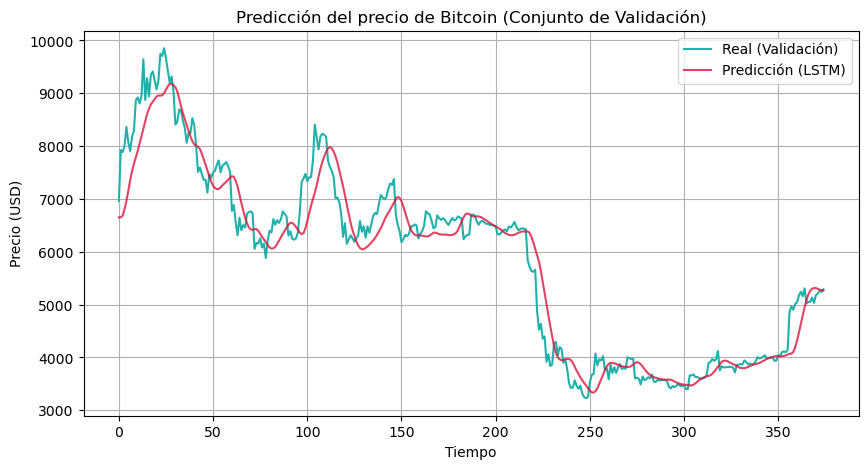

In [43]:
plt.figure(figsize=(10,5))
plt.plot(y_val_inv, label='Real (Validación)', color='lightseagreen')
plt.plot(y_pred_val_inv, label='Predicción (LSTM)', color='crimson', alpha=0.8)
plt.title('Predicción del precio de Bitcoin (Conjunto de Validación)')
plt.xlabel('Tiempo')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
mae = mean_absolute_error(y_val_inv, y_pred_val_inv)
rmse = np.sqrt(mean_squared_error(y_val_inv, y_pred_val_inv))
r2 = r2_score(y_val_inv, y_pred_val_inv)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  310.24
RMSE: 421.76
R²:   0.9417


### **Comparación de desempeño**

Al comparar el desempeño del primer y segundo modelo sobre el conjunto de validación, se observa una mejora considerable en la precisión y la capacidad predictiva del modelo optimizado. El error medio absoluto (MAE) disminuyó de 443.57 a 310.24, y la raíz del error cuadrático medio (RMSE) pasó de 594.43 a 421.76, lo que refleja una reducción notable en la magnitud de los errores de predicción. Asimismo, el coeficiente de determinación (R²) aumentó de 0.8842 a 0.9417, evidenciando que el segundo modelo logra explicar una proporción mayor de la variabilidad del precio del Bitcoin, mostrando así un ajuste más preciso y confiable durante la validación.

## **Resultados: Set de prueba**

In [47]:
# Predicciones
y_pred = model_1.predict(X_test)

# Invertir la normalización para interpretar resultados
# (reconstruimos con el scaler original)
scaled_full = np.zeros((len(y_pred), scaled_data.shape[1]))
scaled_full[:, -1] = y_pred.flatten()
y_pred_original = scaler.inverse_transform(scaled_full)[:, -1]

scaled_full_test = np.zeros((len(y_test), scaled_data.shape[1]))
scaled_full_test[:, -1] = y_test.flatten()
y_test_original = scaler.inverse_transform(scaled_full_test)[:, -1]

# Métricas
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
print(f"RMSE: {rmse:.2f}, R²: {r2:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 740.29, R²: 0.768


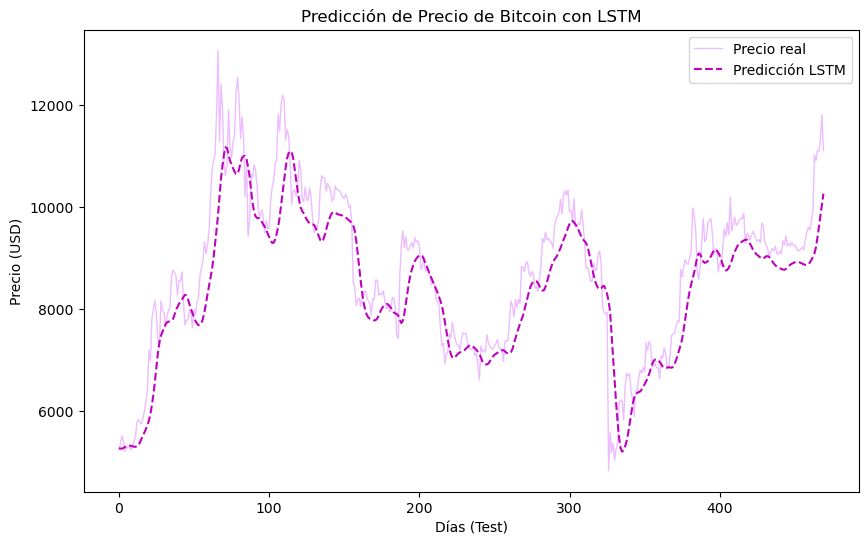

In [61]:
plt.figure(figsize=(10,6))
plt.plot(y_test_original, label='Precio real', color="#edbdff", linewidth=1)
plt.plot(y_pred_original, label='Predicción LSTM', color='m', linestyle='--')
plt.title("Predicción de Precio de Bitcoin con LSTM")
plt.xlabel("Días (Test)")
plt.ylabel("Precio (USD)")
plt.legend()
plt.show()

## **Conclusiones de desempeño**

Al evaluar el segundo modelo con el conjunto de prueba, los resultados se mantienen sólidos, aunque con una ligera disminución en el rendimiento respecto al conjunto de validación. El RMSE aumentó a 740.29 y el R² se redujo a 0.768, lo cual es esperable debido a que el modelo se enfrenta a datos completamente nuevos. Sin embargo, estos valores siguen indicando un buen poder predictivo y una capacidad razonable de generalización, lo que sugiere que el modelo logró capturar adecuadamente las dinámicas temporales más relevantes del comportamiento histórico general del precio del Bitcoin como se muestra en el gráfico anterior.

## **Guardar modelo**

In [63]:
model_1.save("lstm_bitcoin_model.h5")

In [64]:
model_1.save('modelo_lstm_bitcoin.keras')

## **Aplicación**

In [104]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# --- Función auxiliar de preprocesamiento (idéntica a la usada en entrenamiento) ---
def convertir_volumen(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # Detectar signo
    signo = -1 if valor.startswith('-') else 1
    valor = valor.replace('-', '')  # quitar signo

    # Procesar sufijos
    if 'K' in valor:
        numero = float(valor.replace('K', '')) * 1_000
    elif 'M' in valor:
        numero = float(valor.replace('M', '')) * 1_000_000
    else:
        numero = float(valor)  # ya es numérico

    return signo * numero



def predecir_precio_nuevo(ruta_csv, modelo_path):
    # Cargar el modelo entrenado
    model = load_model(modelo_path)

    # Leer los nuevos datos
    df_new = pd.read_csv(ruta_csv)
    df_new = df_new.dropna().reset_index(drop=True)

    # Preprocesamiento coherente con el entrenamiento
    # Eliminar símbolo % 
    df_new['Change %'] = df_new['Change %'].str.replace('%', '').astype(float)

    # Eliminar comas
    for c in ['Price', 'Open', 'High', 'Low']:
        df_new[c] = df_new[c].astype(str).str.replace(',', '').astype(float)

    # Convertir a variables numéricas
    df_new['Vol.'] = df_new['Vol.'].replace('-', np.nan)
    df_new['Vol.'] = df_new['Vol.'].apply(convertir_volumen)

    # Convertir fecha a formato datetime y ordenar
    df_new['Date'] = pd.to_datetime(df_new['Date'])
    df_new.sort_values('Date', inplace=True)



    # Seleccionar solo las columnas usadas para entrenar
    features = ['Open', 'High', 'Low', 'Vol.', 'Change %']
    data = df_new[features].values


    # Escalar con el scaler original o uno nuevo (si no se proporciona)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    # Crear la secuencia (últimos 60 días)
    last_sequence = scaled_data[-60:]
    X_new = np.expand_dims(last_sequence, axis=0) 

    # Realizar la predicción
    pred_scaled = model.predict(X_new)
    # Reconstruir valor original del precio
    inv_input = np.zeros((1, scaled_data.shape[1]))
    inv_input[0, 0] = pred_scaled.item()
    pred = scaler.inverse_transform(inv_input)[0, 0]

    next_date = df_new['Date'].max() + pd.Timedelta(days=1)

    print("\n\n")
    print('='*90)
    print(f"     >>> PRECIO ESTIMADO PARA EL SIGUIENTE DÍA ({next_date.date()}):  $ {pred:,.2f} USD <<<")
    print('='*90, "\n\n")
    return pred

In [105]:
prediccion = predecir_precio_nuevo('Bitcoin Historical Data.csv', 'modelo_lstm_bitcoin.keras')

c:\Users\Ame Contreras\.conda\envs\deepL\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step



     >>> PRECIO ESTIMADO PARA EL SIGUIENTE DÍA (2020-08-03):  $ 10,447.68 USD <<<


